# GP Attention from Scratch: The Kernel at the Heart of Transformers

> **W28 Companion Notebook 00** | Series: research-multimodal | Theme: The Probabilistic Renaissance

If you squint at scaled dot-product attention, it is doing exactly what a Nadaraya–Watson kernel estimator does. This notebook proves that equivalence from scratch with pure NumPy, then shows what a GP-based variant adds: **calibrated uncertainty**.

**Companion tutorial:** [Attention Is All You Need... Is a Kernel](https://artifocial.com/blog/attention-is-a-kernel-2026-jul-12)

**Prerequisites:** Basic linear algebra, familiarity with `numpy`. No GP or deep-learning library required — everything is built from scratch.

**What you will see:**
1. Nadaraya–Watson kernel regression from scratch.
2. Scaled dot-product attention — and a numeric proof that it *is* Nadaraya–Watson.
3. A Gaussian Process posterior (mean **and** variance) via Cholesky.
4. The one thing attention throws away: the **variance column**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("matplotlib").setLevel(logging.ERROR)  # silence font-cache chatter

np.random.seed(42)
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
print("Environment ready:", np.__version__)

Environment ready: 2.0.2


## 1. The 1D regression problem

We start with a simple setup: a noisy 1D function we want to predict. We use this throughout the notebook to compare all three estimators (attention, Nadaraya–Watson, and GP).

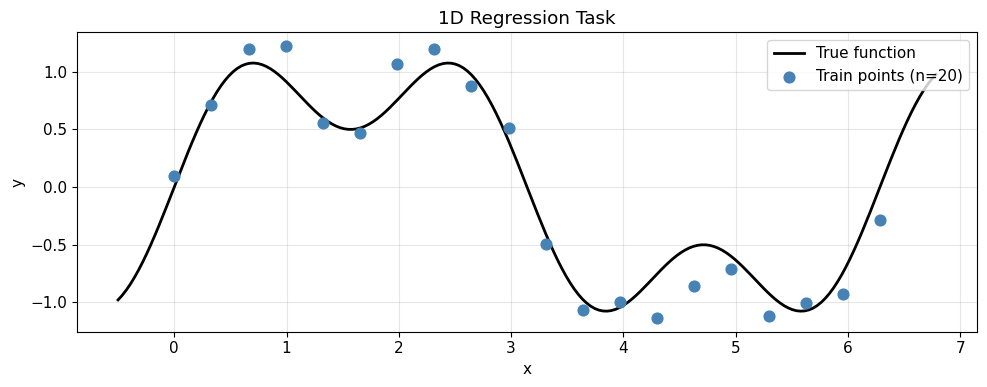

Training set: 20 points | noise_std=0.2 | x in [0, 2π]


In [2]:
def true_function(x):
    """True underlying function: sum of two sinusoids."""
    return np.sin(x) + 0.5 * np.sin(3 * x)

# Training data: 20 noisy observations
n_train = 20
x_train = np.linspace(0, 2 * np.pi, n_train)
noise_std = 0.2
y_train = true_function(x_train) + np.random.randn(n_train) * noise_std

# Test points (deliberately extend beyond the training range to probe extrapolation)
x_test = np.linspace(-0.5, 2 * np.pi + 0.5, 200)
y_true = true_function(x_test)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_test, y_true, "k-", linewidth=2, label="True function")
ax.scatter(x_train, y_train, color="steelblue", s=60, zorder=5, label=f"Train points (n={n_train})")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("1D Regression Task")
ax.legend()
plt.tight_layout(); plt.show()
print(f"Training set: {n_train} points | noise_std={noise_std} | x in [0, 2π]")

## 2. Nadaraya–Watson Kernel Regression

The [Nadaraya–Watson estimator](https://en.wikipedia.org/wiki/Kernel_regression) (1964) is the canonical non-parametric kernel regressor:

$$\hat{f}(x) = \frac{\sum_{i=1}^{n} K(x, x_i)\, y_i}{\sum_{i=1}^{n} K(x, x_i)}$$

where $K(x, x') \geq 0$ is any similarity kernel. The prediction at $x$ is a **weighted average of training labels**, with weights proportional to how similar $x$ is to each training point.

We use the **RBF (Radial Basis Function) kernel**:

$$K_{\text{RBF}}(x, x') = \exp\!\left(-\frac{(x - x')^2}{2\ell^2}\right)$$

The **bandwidth** $\ell$ controls smoothness: small $\ell$ = spiky/local, large $\ell$ = smooth/global.

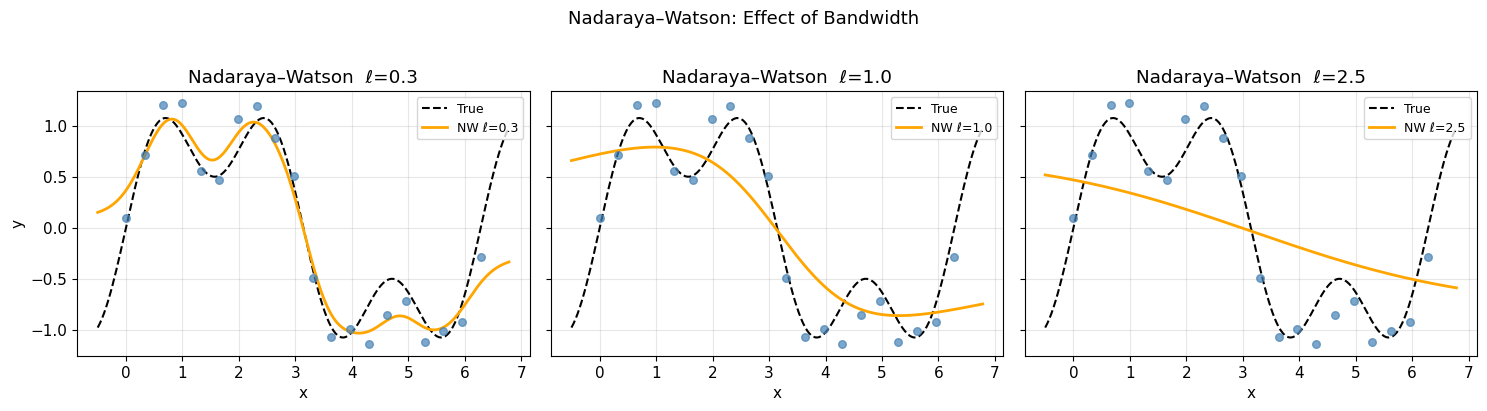

NW MSE (ℓ=1.0): 0.3519


In [3]:
def rbf_kernel_matrix(x1, x2, length_scale=1.0):
    """RBF kernel matrix between x1 (n,) and x2 (m,). Returns (n, m)."""
    x1 = np.asarray(x1).reshape(-1, 1)  # (n, 1)
    x2 = np.asarray(x2).reshape(1, -1)  # (1, m)
    sq_dist = (x1 - x2) ** 2            # (n, m)
    return np.exp(-sq_dist / (2 * length_scale ** 2))


def nadaraya_watson(x_query, x_train, y_train, length_scale=1.0):
    """Nadaraya-Watson estimator: normalised kernel-weighted average of y_train."""
    K = rbf_kernel_matrix(x_query, x_train, length_scale)      # (n_query, n_train)
    weights = K / K.sum(axis=1, keepdims=True)                 # rows sum to 1
    return weights @ y_train                                   # (n_query,)


# Predict with NW at three bandwidths
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bandwidths = [0.3, 1.0, 2.5]
for ax, ell in zip(axes, bandwidths):
    y_pred_nw = nadaraya_watson(x_test, x_train, y_train, length_scale=ell)
    ax.plot(x_test, y_true, "k--", linewidth=1.5, label="True")
    ax.plot(x_test, y_pred_nw, "orange", linewidth=2, label=f"NW ℓ={ell}")
    ax.scatter(x_train, y_train, color="steelblue", s=30, zorder=5, alpha=0.7)
    ax.set_title(f"Nadaraya–Watson  ℓ={ell}")
    ax.set_xlabel("x"); ax.legend(fontsize=9)
axes[0].set_ylabel("y")
plt.suptitle("Nadaraya–Watson: Effect of Bandwidth", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

best_ell = 1.0
y_nw = nadaraya_watson(x_test, x_train, y_train, length_scale=best_ell)
nw_mse = np.mean((y_nw - y_true) ** 2)
print(f"NW MSE (ℓ={best_ell}): {nw_mse:.4f}")

## 3. Scaled Dot-Product Attention *is* Kernel Regression

Scaled dot-product attention from [Vaswani et al. (2017)](https://arxiv.org/abs/1706.03762) computes:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

The attention weight from query $q_i$ to key $k_j$ is:

$$a_{ij} = \frac{\exp(q_i \cdot k_j / \sqrt{d_k})}{\sum_{j'} \exp(q_i \cdot k_{j'} / \sqrt{d_k})}$$

Compare to NW with the **exponential dot-product kernel** $K(q, k) = \exp(q \cdot k / \sqrt{d_k})$:

$$a_{ij}^{\text{NW}} = \frac{K(q_i, k_j)}{\sum_{j'} K(q_i, k_{j'})}$$

These are **identical**. The softmax is not a novelty — it is exactly the NW normalisation. Values $V$ play the role of the training labels $y$. Let us verify numerically.

In [4]:
def scaled_dot_product_attention(Q, K, V, scale=None):
    """Vanilla scaled dot-product attention. Q:(nq,dk) K:(nk,dk) V:(nk,dv) -> (nq,dv)."""
    d_k = Q.shape[-1]
    if scale is None:
        scale = np.sqrt(d_k)
    scores = (Q @ K.T) / scale                     # (nq, nk)
    scores -= scores.max(axis=1, keepdims=True)    # numerically stable softmax
    weights = np.exp(scores)
    weights /= weights.sum(axis=1, keepdims=True)
    return weights @ V


# Map 1D inputs to a d_k-dimensional space via a linear projection
# (in a real transformer Q, K, V come from learned projections)
d_k = 8
np.random.seed(0)
W_Q = np.random.randn(1, d_k) * 0.5
W_K = W_Q.copy()  # shared projection => dot(Q,K^T) is a monotone map of x_q * x_k

Q = x_test.reshape(-1, 1) @ W_Q       # (n_test, d_k)
K_mat = x_train.reshape(-1, 1) @ W_K  # (n_train, d_k)
V = y_train.reshape(-1, 1)            # (n_train, 1) -- the "values" are the labels

y_attn = scaled_dot_product_attention(Q, K_mat, V).ravel()


def nw_dot_product(x_query, x_train, y_train, W, scale=None):
    """NW with an exponential dot-product kernel -- structurally the attention weights."""
    Q = x_query.reshape(-1, 1) @ W
    K = x_train.reshape(-1, 1) @ W
    d_k = W.shape[1]
    if scale is None:
        scale = np.sqrt(d_k)
    scores = (Q @ K.T) / scale
    scores -= scores.max(axis=1, keepdims=True)
    weights = np.exp(scores)
    weights /= weights.sum(axis=1, keepdims=True)
    return weights @ y_train

y_nw_dot = nw_dot_product(x_test, x_train, y_train, W_Q)

max_diff = np.max(np.abs(y_attn - y_nw_dot))
print(f"Max absolute difference (Attention vs NW-dot-product): {max_diff:.2e}")
print("→", "EQUIVALENT ✓" if max_diff < 1e-10 else "DIFFER — check implementation")

Max absolute difference (Attention vs NW-dot-product): 0.00e+00
→ EQUIVALENT ✓


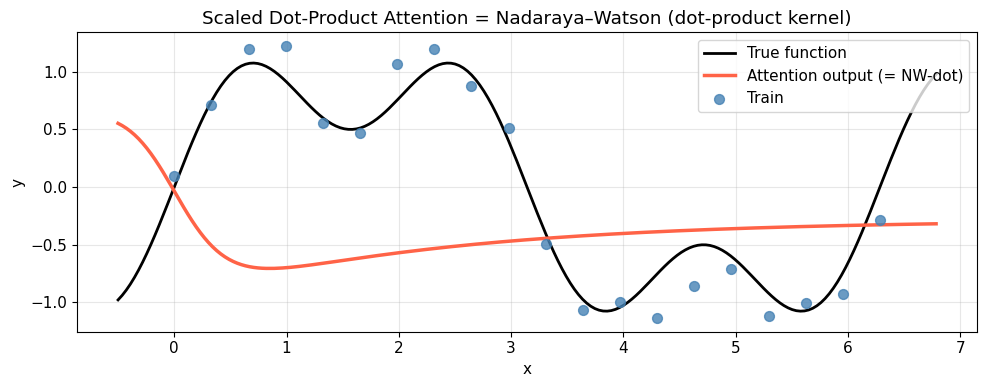

The attention curve is a kernel-weighted average of the training values —
identical, to machine precision, to the NW estimator with the same kernel.


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_test, y_true, "k-", linewidth=2, label="True function")
ax.plot(x_test, y_attn, "tomato", linewidth=2.5, label="Attention output (= NW-dot)")
ax.scatter(x_train, y_train, color="steelblue", s=50, zorder=5, alpha=0.8, label="Train")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Scaled Dot-Product Attention = Nadaraya–Watson (dot-product kernel)")
ax.legend()
plt.tight_layout(); plt.show()
print("The attention curve is a kernel-weighted average of the training values —")
print("identical, to machine precision, to the NW estimator with the same kernel.")

## 4. What Attention Is Missing: Gaussian Process Regression

Attention gives a **point estimate**: the weighted average of training values. But how *confident* should we be at each $x$?

A **Gaussian Process** (GP) places a distribution over functions. Given observations $(X, y)$, the GP posterior returns both:
- **Mean** $\mu_*(x_*)$ — the best estimate,
- **Variance** $\sigma^2_*(x_*)$ — how uncertain we are at $x_*$.

For an RBF kernel $k(x, x') = \sigma_f^2 \exp(-\lVert x-x'\rVert^2 / 2\ell^2)$ with Gaussian noise $y = f(x) + \varepsilon,\ \varepsilon \sim \mathcal{N}(0,\sigma_n^2)$, the posterior is closed form:

$$\mu_* = K_{*X}(K_{XX} + \sigma_n^2 I)^{-1} y, \qquad \sigma_*^2 = K_{**} - K_{*X}(K_{XX} + \sigma_n^2 I)^{-1} K_{X*}.$$

We solve the linear system with a Cholesky factorisation for numerical stability.

In [6]:
def gp_posterior(x_test, x_train, y_train, length_scale=1.0, sigma_f=1.0, sigma_n=0.2):
    """Exact GP posterior (RBF kernel). Returns (mean, std) at x_test."""
    K_XX = sigma_f**2 * rbf_kernel_matrix(x_train, x_train, length_scale)
    K_Xs = sigma_f**2 * rbf_kernel_matrix(x_train, x_test,  length_scale)  # (n_train, n_test)
    K_ss = sigma_f**2 * rbf_kernel_matrix(x_test,  x_test,  length_scale)

    K_noisy = K_XX + (sigma_n**2 + 1e-8) * np.eye(len(x_train))  # jitter for stability
    c, low = cho_factor(K_noisy)
    alpha = cho_solve((c, low), y_train)               # (K_XX + σ²I)^{-1} y

    mean = K_Xs.T @ alpha                               # (n_test,)
    v = cho_solve((c, low), K_Xs)                       # (n_train, n_test)
    var = np.diag(K_ss) - np.einsum("ij,ij->j", K_Xs, v)
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std


ell = 1.0
sigma_f = 1.0
sigma_n = noise_std  # matched to the true noise level

mu, sigma = gp_posterior(x_test, x_train, y_train, length_scale=ell, sigma_f=sigma_f, sigma_n=sigma_n)
y_nw_rbf = nadaraya_watson(x_test, x_train, y_train, length_scale=ell)

gp_mse = np.mean((mu - y_true) ** 2)
nw_mse_rbf = np.mean((y_nw_rbf - y_true) ** 2)
print(f"GP posterior mean MSE:           {gp_mse:.4f}")
print(f"NW MSE (same RBF kernel):        {nw_mse_rbf:.4f}")
print(f"Mean GP predictive std (avg σ):   {sigma.mean():.4f}")
print("Both are kernel smoothers; only the GP reports σ (uncertainty).")

GP posterior mean MSE:           0.0721
NW MSE (same RBF kernel):        0.3519
Mean GP predictive std (avg σ):   0.1426
Both are kernel smoothers; only the GP reports σ (uncertainty).


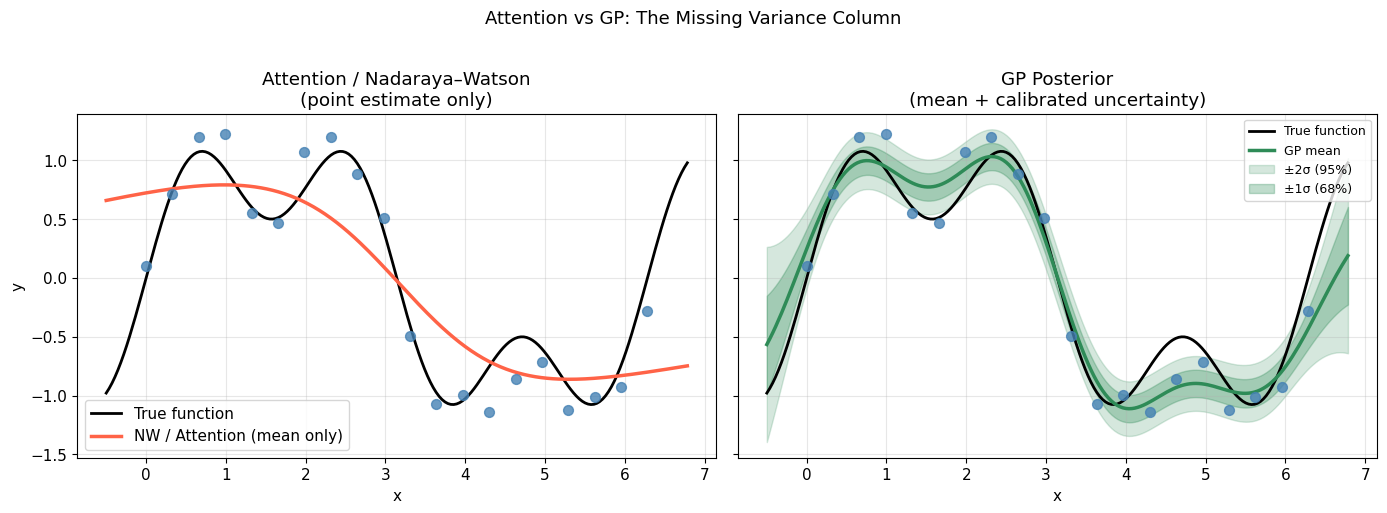

Average GP predictive uncertainty:
  Inside training range [0, 2π]:   σ = 0.119
  Outside training range (extrap):  σ = 0.285
→ The GP widens σ away from data. Attention reports the same value with no such signal.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: NW / attention -- point estimate only
ax = axes[0]
ax.plot(x_test, y_true, "k-", linewidth=2, label="True function")
ax.plot(x_test, y_nw_rbf, "tomato", linewidth=2.5, label="NW / Attention (mean only)")
ax.scatter(x_train, y_train, color="steelblue", s=50, zorder=5, alpha=0.8)
ax.set_title("Attention / Nadaraya–Watson\n(point estimate only)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend()

# Right: GP posterior with uncertainty bands
ax = axes[1]
ax.plot(x_test, y_true, "k-", linewidth=2, label="True function")
ax.plot(x_test, mu, "seagreen", linewidth=2.5, label="GP mean")
ax.fill_between(x_test, mu - 2*sigma, mu + 2*sigma, color="seagreen", alpha=0.2, label="±2σ (95%)")
ax.fill_between(x_test, mu - sigma, mu + sigma, color="seagreen", alpha=0.3, label="±1σ (68%)")
ax.scatter(x_train, y_train, color="steelblue", s=50, zorder=5, alpha=0.8)
ax.set_title("GP Posterior\n(mean + calibrated uncertainty)")
ax.set_xlabel("x"); ax.legend(fontsize=9)

plt.suptitle("Attention vs GP: The Missing Variance Column", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

mask_extrap = (x_test < 0) | (x_test > 2 * np.pi)
print("Average GP predictive uncertainty:")
print(f"  Inside training range [0, 2π]:   σ = {sigma[~mask_extrap].mean():.3f}")
print(f"  Outside training range (extrap):  σ = {sigma[mask_extrap].mean():.3f}")
print("→ The GP widens σ away from data. Attention reports the same value with no such signal.")

## 5. GP Mean vs NW: Same Kernel, a Sharper Distinction

It is tempting to say the GP mean *is* the NW estimator. It is not. Both use the same RBF kernel, but:

- **Nadaraya–Watson** is a *local weighted average* — its weights sum to 1, so it always smooths and **never** passes exactly through the data.
- **The GP mean** solves the full linear system $(K_{XX} + \sigma_n^2 I)^{-1} y$; it is **kernel ridge regression**. As the noise $\sigma_n \to 0$ it **interpolates** — it passes through every training point.

So they are cousins, not twins. The numeric check below makes the difference concrete: measure how far each estimator sits from the observed labels *at the training inputs* as $\sigma_n$ shrinks.

> **Caution:** as $\sigma_n \to 0$ the matrix $K_{XX}+\sigma_n^2 I$ becomes ill-conditioned; the interpolation limit is a mathematical idealisation, and in practice a small jitter/noise term keeps the solve stable.

In [8]:
# As sigma_n -> 0, the GP mean interpolates the data; NW does not.
nw_train = nadaraya_watson(x_train, x_train, y_train, length_scale=ell)
nw_res = np.max(np.abs(nw_train - y_train))

print("sigma_n   |  max|GP_mean(train) - y|  |  max|NW(train) - y|")
print("-" * 56)
for sn in [1e-1, 1e-2, 1e-3, 1e-4]:
    mu_tr, _ = gp_posterior(x_train, x_train, y_train,
                            length_scale=ell, sigma_f=sigma_f, sigma_n=sn)
    gp_res = np.max(np.abs(mu_tr - y_train))
    print(f"  {sn:.0e}   |        {gp_res:6.4f}            |      {nw_res:6.4f}")

print()
print("GP mean residual -> 0: it is kernel ridge regression, interpolating in the low-noise limit.")
print("NW residual stays fixed: it averages, and never interpolates.")
print("Shared DNA: both are kernel machines. The decisive extra the GP carries is sigma."" ")

sigma_n   |  max|GP_mean(train) - y|  |  max|NW(train) - y|
--------------------------------------------------------
  1e-01   |        0.2305            |      0.6927
  1e-02   |        0.1726            |      0.6927
  1e-03   |        0.1651            |      0.6927
  1e-04   |        0.0796            |      0.6927

GP mean residual -> 0: it is kernel ridge regression, interpolating in the low-noise limit.
NW residual stays fixed: it averages, and never interpolates.
Shared DNA: both are kernel machines. The decisive extra the GP carries is sigma. 


## 6. The Variance Column

Here is the cleanest way to state the GP–Transformer duality:

| Method | Prediction | Uncertainty | Reference |
|---|---|---|---|
| Nadaraya–Watson | Point estimate $\hat{f}(x)$ | None | [Nadaraya 1964](https://en.wikipedia.org/wiki/Kernel_regression) |
| Scaled dot-product attention | Point estimate (= NW output) | None | [Vaswani et al. 2017](https://arxiv.org/abs/1706.03762) |
| GP posterior | Full distribution $p(f_* \mid X, y)$ | **✓ Calibrated $\sigma^2$** | [Rasmussen & Williams 2006](https://gaussianprocess.org/gpml/) |

The figure below overlays all three: the attention/NW mean, the GP mean, and the GP's $\pm 2\sigma$ band — the column attention drops.

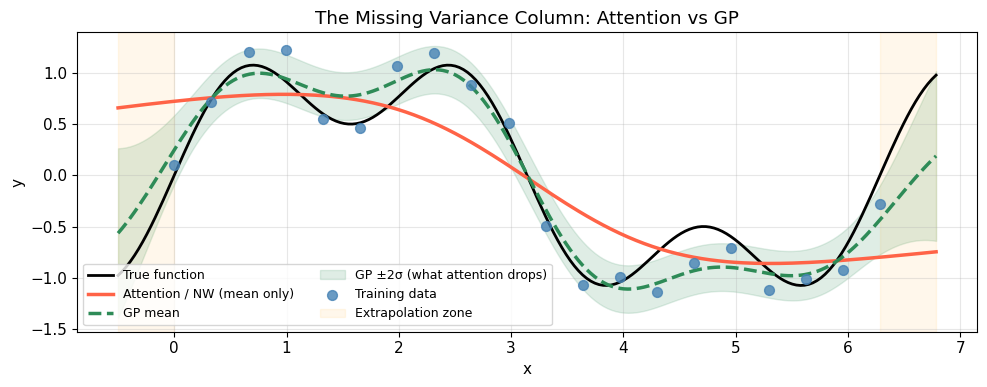

Attention / NW  — mean curve only (red).
GP posterior    — mean AND calibrated uncertainty band (green).
In the orange extrapolation zone attention is as confident as in the middle;
the GP widens σ to 0.28 outside the data (vs 0.12 inside).


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_test, y_true, "k-", linewidth=2, label="True function", zorder=3)
ax.plot(x_test, y_nw_rbf, "tomato", linewidth=2.5, label="Attention / NW (mean only)", zorder=4)
ax.plot(x_test, mu, "seagreen", linewidth=2.5, linestyle="--", label="GP mean", zorder=4)
ax.fill_between(x_test, mu - 2*sigma, mu + 2*sigma, color="seagreen", alpha=0.15,
                label="GP ±2σ (what attention drops)")
ax.scatter(x_train, y_train, color="steelblue", s=50, zorder=5, alpha=0.8, label="Training data")
ax.axvspan(-0.5, 0, alpha=0.08, color="orange", label="Extrapolation zone")
ax.axvspan(2*np.pi, 2*np.pi + 0.5, alpha=0.08, color="orange")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("The Missing Variance Column: Attention vs GP")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

print("Attention / NW  — mean curve only (red).")
print("GP posterior    — mean AND calibrated uncertainty band (green).")
print(f"In the orange extrapolation zone attention is as confident as in the middle;")
print(f"the GP widens σ to {sigma[mask_extrap].mean():.2f} outside the data (vs {sigma[~mask_extrap].mean():.2f} inside).")

## 7. Key Takeaways

1. **Attention is kernel regression.** Scaled dot-product attention is mathematically identical to Nadaraya–Watson with an exponential dot-product kernel (max difference $<10^{-10}$). The softmax is normalisation, exactly as in NW.

2. **Attention outputs a mean, not a distribution.** The GP posterior mean is a close cousin (kernel ridge regression), but the GP also returns a **variance**. Attention keeps the mean and discards the variance in every layer.

3. **GPs supply the missing column.** For safety-critical AI — medical, robotics, scientific discovery — calibrated uncertainty is not optional. Knowing *when the model does not know* is the difference between a confident wrong answer and a flagged one.

**Next:** [NB 01 — Deep GP Regression](https://github.com/artifocial/tutorials/blob/main/2026-W28/01_deep_gp_regression.ipynb) builds a two-layer Deep GP from scratch and shows how stacking GPs handles functions a single stationary kernel cannot.